In [1]:
# ============================================================
# 소비패턴 데이터 탐정 - Pandas 분석 (Q1, Q2)
# Q1. 어떤 카테고리에 지출이 가장 많이 몰리는가? (금액, 건수, 비중)
# Q2. 큰 금액 거래는 어떤 특징이 있는가? (기준: 150,000원 초과)
# ============================================================
import pandas as pd                 # 표(DataFrame)를 다루는 라이브러리
import matplotlib.pyplot as plt     # 차트를 그리는 라이브러리

In [2]:
# ------------------------------------------------------------
# 0. 데이터 불러오기 + 기본 점검
# ------------------------------------------------------------
categories = pd.read_csv("data/categories.csv")   # 카테고리 코드표
customers = pd.read_csv("data/customers.csv")     # 고객 정보
merchants = pd.read_csv("data/merchants.csv")     # 가맹점 정보
df = pd.read_csv("data/transactions.csv")         # 거래내역 (이번 분석의 주인공)
 
print(df.shape)                    # (행 수, 열 수) -> (1200, 9)면 정상
df.info()                          # 열별 자료형, 비어있지 않은 값 개수(결측 확인)
print(df["amount"].describe())     # 금액의 평균, 중앙값, 최대 등 요약

(1200, 9)
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   date            1200 non-null   str  
 1   transaction_id  1200 non-null   str  
 2   type            1200 non-null   str  
 3   category        1200 non-null   str  
 4   amount          1200 non-null   int64
 5   customer_id     1200 non-null   str  
 6   merchant_id     1200 non-null   str  
 7   time            1200 non-null   str  
 8   channel         1200 non-null   str  
dtypes: int64(1), str(8)
memory usage: 84.5 KB
count      1200.000000
mean      45547.166667
std       72121.504085
min        1600.000000
25%       12175.000000
50%       22650.000000
75%       51450.000000
max      564300.000000
Name: amount, dtype: float64


In [3]:
# ------------------------------------------------------------
# Q1. 카테고리별 지출 (금액, 건수, 비중)
# ------------------------------------------------------------
# 같은 카테고리끼리 묶어서, 금액 합계(total)와 거래 건수(count)를 구함
summary = df.groupby("category")["amount"].agg(total="sum", count="count")
 
# 비중(%) = 카테고리 합계 / 전체 합계 * 100, 소수 첫째 자리까지 반올림
summary["ratio"] = (summary["total"] / summary["total"].sum() * 100).round(1)
 
# 합계가 큰 카테고리가 위로 오도록 정렬
summary = summary.sort_values("total", ascending=False)
print(summary)

                 total  count  ratio
category                            
GROCERY       11664100    213   21.3
SHOPPING      10563200    110   19.3
FOOD           9850600    324   18.0
LEISURE        5591900     87   10.2
SUBSCRIPTION   4008900     86    7.3
HEALTH         3808300     68    7.0
EDUCATION      3551100     48    6.5
TRANSPORT      3379500    126    6.2
CAFE           2239000    138    4.1


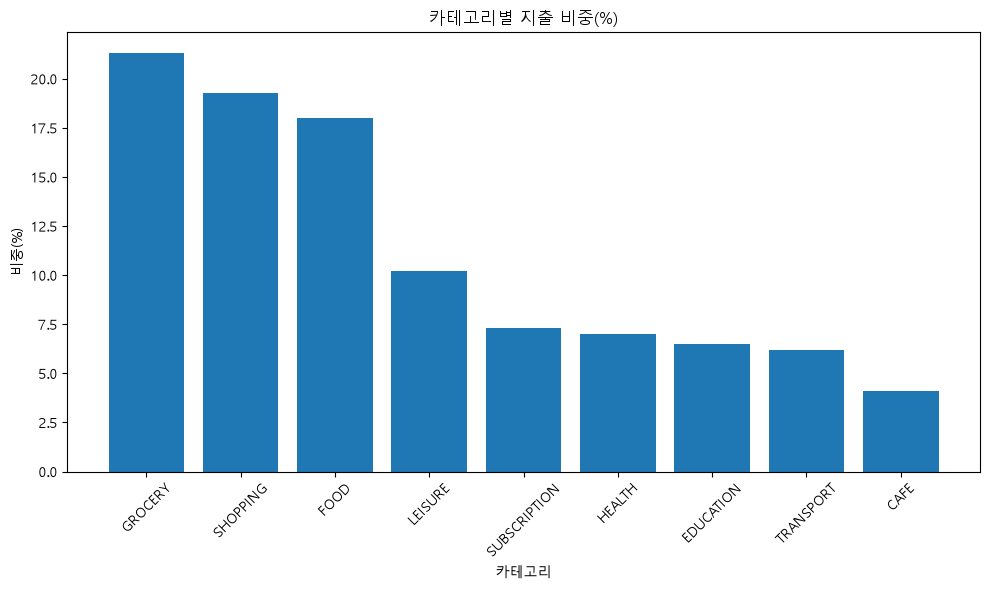

In [4]:
# ----- Q1 차트: 카테고리별 지출 비중 막대 그래프 -----
plt.rcParams["font.family"] = "Malgun Gothic"   # 한글 깨짐 방지 (Windows 기본 폰트)
plt.rcParams["axes.unicode_minus"] = False      # 마이너스 기호 깨짐 방지
 
plt.figure(figsize=(10, 6))                     # 그림 크기 (가로 10, 세로 6)
plt.bar(summary.index, summary["ratio"])        # x: 카테고리 이름, y: 비중(%)
plt.title("카테고리별 지출 비중(%)")
plt.xlabel("카테고리")
plt.ylabel("비중(%)")
plt.xticks(rotation=45)                         # 카테고리 이름이 안 겹치게 기울임
plt.tight_layout()                              # 글자가 잘리지 않게 여백 자동 조정
plt.show()                                      # 화면에 표시

In [5]:
# ------------------------------------------------------------
# Q2. 큰 금액 거래 (팀 기준: 150,000원 초과)
# ------------------------------------------------------------
THRESHOLD = 150000    # 기준 금액. 바뀌면 이 한 줄만 고치면 됨
 
# 금액이 기준보다 큰 행만 골라서 복사본으로 저장 (.copy()는 독립된 표로 만들기)
big = df[df["amount"] > THRESHOLD].copy()
print(len(big))              # 고액 거래 건수 -> 55
print(big["amount"].sum())   # 고액 거래 금액 합계 -> 18028000
 
# 금액이 큰 순서로 정렬해서 상위 10건 확인
top10 = big.sort_values("amount", ascending=False).head(10)
print(top10[["date", "category", "amount", "channel"]])   # 필요한 열만 골라서 출력

55
18028000
            date      category  amount channel
744   2026-04-22      SHOPPING  564300   STORE
266   2026-02-09       GROCERY  559600   STORE
666   2026-04-13  SUBSCRIPTION  558000   STORE
265   2026-02-09      SHOPPING  540700   STORE
368   2026-02-23      SHOPPING  533600     APP
587   2026-04-03       GROCERY  530100   STORE
921   2026-05-20        HEALTH  516700     WEB
824   2026-05-05          FOOD  491100     APP
165   2026-01-25          FOOD  485800     WEB
1085  2026-06-14     EDUCATION  476400   STORE


In [6]:
# ----- (a) 고액 거래의 카테고리별 특징 -----
big_cat = big.groupby("category")["amount"].agg(total="sum", count="count")
big_cat["ratio"] = (big_cat["total"] / big_cat["total"].sum() * 100).round(1)
big_cat = big_cat.sort_values("total", ascending=False)
print(big_cat)

                total  count  ratio
category                           
FOOD          4175700     13   23.2
SUBSCRIPTION  2931500     10   16.3
SHOPPING      2626200      7   14.6
GROCERY       2102900      5   11.7
TRANSPORT     1984000      7   11.0
HEALTH        1633100      5    9.1
CAFE          1248900      4    6.9
EDUCATION      669000      2    3.7
LEISURE        656700      2    3.6


In [7]:
# ----- (b) 고액 거래의 월별 특징 -----
# date는 "2026-04-22" 같은 문자열이라, 앞 7글자("2026-04")만 잘라 월 열을 만듦
big["month"] = big["date"].str[:7]
big_month = big.groupby("month")["amount"].agg(total="sum", count="count")
print(big_month)

           total  count
month                  
2026-01  3137800     12
2026-02  3858600     11
2026-03   696500      2
2026-04  4469200     13
2026-05  2594400      7
2026-06  3271500     10


In [8]:
# ----- (c) 고액 거래의 채널별 특징 -----
print(big["channel"].value_counts())   # 채널별로 몇 건인지 셈

channel
STORE    25
APP      17
WEB      13
Name: count, dtype: int64


In [9]:
# ------------------------------------------------------------
# 인사이트에 쓴 숫자 검증 (문장의 숫자가 코드로 확인되는지 점검)
# ------------------------------------------------------------
print(summary["total"].sum())                                                   # 전체 합계 -> 54656600
print((summary["total"] / summary["count"]).round(0))                           # 카테고리별 건당 평균
print(round(summary["total"].head(3).sum() / summary["total"].sum() * 100, 1))  # 상위 3개 비중 -> 58.7
print(round(summary.loc["FOOD", "count"] / len(df) * 100, 1))                   # 식비 건수 비중 -> 27.0
print(round(len(big) / len(df) * 100, 1))                                       # 고액 건수 비중 -> 4.6
print(round(big["amount"].sum() / df["amount"].sum() * 100, 1))                 # 고액 금액 비중 -> 33.0
 
# 카테고리별 고액 비율 = 그 카테고리 고액 건수 / 그 카테고리 전체 건수
# (두 표가 카테고리 이름으로 자동으로 맞춰져서 나눠짐)
big_rate = (big_cat["count"] / summary["count"] * 100).round(1)
print(big_rate.sort_values(ascending=False))                                    # 구독이 맨 위 -> 11.6

54656600
category
GROCERY         54761.0
SHOPPING        96029.0
FOOD            30403.0
LEISURE         64275.0
SUBSCRIPTION    46615.0
HEALTH          56004.0
EDUCATION       73981.0
TRANSPORT       26821.0
CAFE            16225.0
dtype: float64
58.7
27.0
4.6
33.0
category
SUBSCRIPTION    11.6
HEALTH           7.4
SHOPPING         6.4
TRANSPORT        5.6
EDUCATION        4.2
FOOD             4.0
CAFE             2.9
GROCERY          2.3
LEISURE          2.3
Name: count, dtype: float64


In [10]:
# ------------------------------------------------------------
# SQL 결과와 비교할 수치표
# ------------------------------------------------------------
display(summary)      # Q1: 카테고리별 금액·건수·비중
display(big_cat)      # Q2: 고액 거래 카테고리별
display(big_month)    # Q2: 고액 거래 월별

,total,count,ratio
category,,,
GROCERY,11664100,213,21.3
SHOPPING,10563200,110,19.3
FOOD,9850600,324,18.0
LEISURE,5591900,87,10.2
SUBSCRIPTION,4008900,86,7.3
HEALTH,3808300,68,7.0
EDUCATION,3551100,48,6.5
TRANSPORT,3379500,126,6.2
CAFE,2239000,138,4.1


,total,count,ratio
category,,,
FOOD,4175700,13,23.2
SUBSCRIPTION,2931500,10,16.3
SHOPPING,2626200,7,14.6
GROCERY,2102900,5,11.7
TRANSPORT,1984000,7,11.0
HEALTH,1633100,5,9.1
CAFE,1248900,4,6.9
EDUCATION,669000,2,3.7
LEISURE,656700,2,3.6


,total,count
month,,
2026-01,3137800,12
2026-02,3858600,11
2026-03,696500,2
2026-04,4469200,13
2026-05,2594400,7
2026-06,3271500,10


In [11]:
# ------------------------------------------------------------
# [핵심 인사이트]
# ------------------------------------------------------------
# 지출은 상위 3개 카테고리에 집중된다. 장보기(21.3%), 쇼핑(19.3%), 식비(18.0%)가 전체 지출 약 5,466만 원의 58.7%를 차지한다. 식비는 건수가 324건(27.0%)으로 가장 많지만 건당 평균이 약 30,403원이라 금액 순위는 3위다.
# 고액 거래(15만 원 초과)는 건수는 적지만 금액 비중이 크다. 55건으로 전체의 4.6%지만 금액으로는 18,028,000원, 전체의 33.0%를 차지한다. 고액 거래는 식비 13건(23.2%)이 가장 많고, 구독 10건(16.3%)이 뒤를 잇는다.
# 시기와 카테고리별 고액 비율에 차이가 있다. 고액 거래는 3월에 2건뿐이고 나머지 달은 7~13건이다. 카테고리 안에서 고액 거래가 차지하는 비율은 구독이 11.6%(86건 중 10건)로 가장 높다.